In [1]:
# USUAL IMPORTS
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# IMPORT FROM OUR MODULE
import helpers as hp

# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)

# Parameters
Ntsteps = 5000

Ref. "A Statistical Framework for Neuroimaging data Analysis Based on Mutual Information Estimated via a Gaussian Copula"

# **WHAT CAN MI ESTIMATE**
- MI between neural variable and an external signal
- MI between two neural variables
- Transfer entropy/Granger causality :: CMI between two neural variables

_NOTICE:_ The key idea is that MI should detect **any statistical dependence**. The main issue is how to estimate MI though. 

# **SIMULATED DATA**
1) Simulate an external signal $S(t)$ and a neural variable $X(t)$ with three different types of relation with or without lag. 

    Types: 
    - linear
    - monotonic non linear
    - non monotonic (quadratic for example)
 
2) Compute MI (with or without lag, and maybe conditioning on $X(t-1)$) with different methods. 
    
    Methods: 
    - Gaussian (assuming joint normality)
    - Binning 
    - KDE ** maybe ** 
    - Gaussian copula 

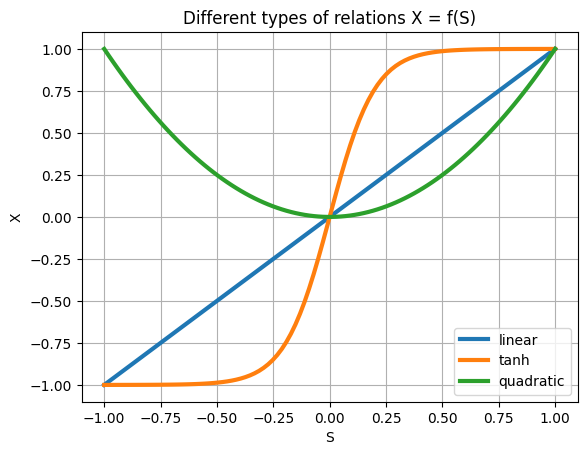

In [9]:
S = np.linspace(-1, +1, 100)

relations = ["linear", "tanh", "quadratic"]

X = np.vstack([hp.generate_neural_variable(S, noise_std = 0),
            hp.generate_neural_variable(S, relation = relations[1], noise_std = 0),
            hp.generate_neural_variable(S, relation = relations[2], noise_std = 0)])


fig, ax = plt.subplots()
for i, relation in enumerate(relations):
    ax.plot(S, X[i, :], label = relations[i], lw = 3)


ax.set_xlabel("S")
ax.set_ylabel("X")
ax.set_title("Different types of relations X = f(S)")
ax.grid()
ax.legend()

## GENERATING SYNTHETIC NEURAL DATA

Let's start simple! We generate an external signal $S(t) \sim \mathcal{N}(0,1)$ (i.i.d. random variables, no temporal structure). 

On that we generate the neural variable: $X(t) = f(S(t)) + \eta(t)$, with $\eta(t) \sim \mathcal{N}(0,\sigma^2)$ being the additional noise.  

In [3]:
# External signal (stimulus)
S = np.random.normal(0, 1, Ntsteps) # You can try change mu see how quad joint distribution changes!
# hp.plot_ts_and_hist(S, "external signal S(t)", color = "steelblue")

#### Linear relationship
$$
X(t) = S(t) + \eta(t)
$$

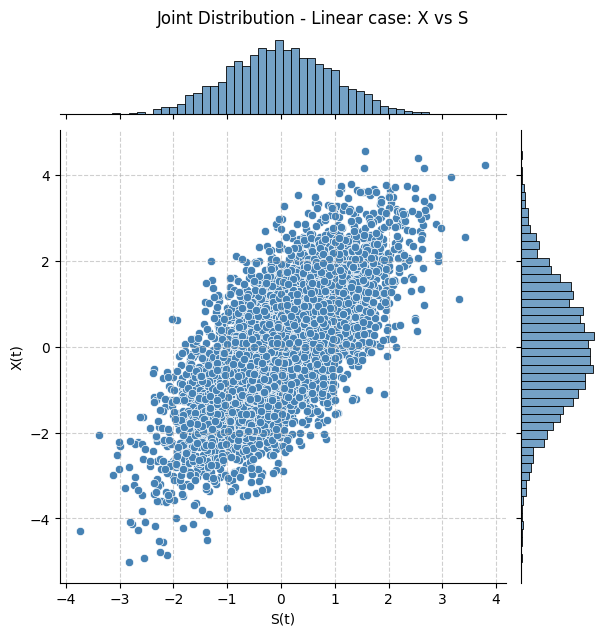

In [4]:
# ------ Linear, no AR, no LAG ------------
X_linear = hp.generate_neural_variable(S, noise_std = 1) # --> we can change also the noise strength from here directly! (Default is 1)
# ------ Linear, no AR, LAG of 2 ---------------
# X_linear = hp.generate_neural_variable(S, lag = True, tau = 2)
# ------ Linear, AR, no LAG ---------------
# X_linear = hp.generate_neural_variable(S, auto_regr=True)

#hp.plot_ts(X_linear, r"$X(t) = a\,S(t) + \eta$, a = 1", color = "forestgreen") # no autoregression and no temporal structure of S(t), so there is no need to plot the time series
#hp.plot_hist(X_linear, r"$X(t) = a\,S(t) + \eta$, a = 1", xlabel = "X", color = "forestgreen")
#hp.plot_joint_distribution(S, X_linear, 
#                           title_string="Linear case: X vs S",
#                           color="forestgreen") #, density = True)

hp.plot_joint_distribution_sns(S, X_linear, title_string = "Linear case: X vs S")

#### Monotonic nonlinear
$$
X(t) = S(t)^3 + \eta(t)
$$

OR 

$$
X(t) = \tanh[S(t)] + \eta(t)
$$

_NOTICE_: tanh is nice because it is smooth and monotonically increasing as the cubic, but it is also saturating (thus "neuron-like" and not exploding numerically). 

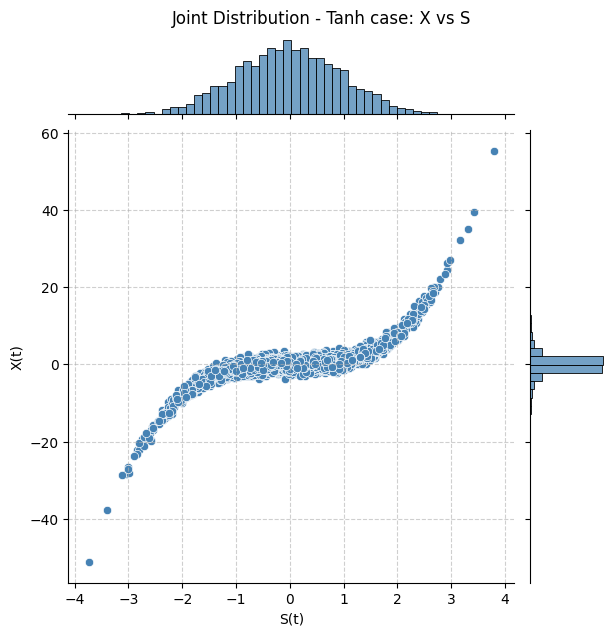

In [5]:
# ------ Cubic, no AR, no LAG ------------
X_cub = hp.generate_neural_variable(S, relation="cubic")
#hp.plot_ts_and_hist(X_cub, r"$X(t) = S(t)^3 + \eta$", color = "gold")
#hp.plot_joint_distribution(S, X_cub,
#                           title_string="Cubic case: X vs S",
#                           color="gold")


hp.plot_joint_distribution_sns(S, X_cub, title_string = "Tanh case: X vs S")

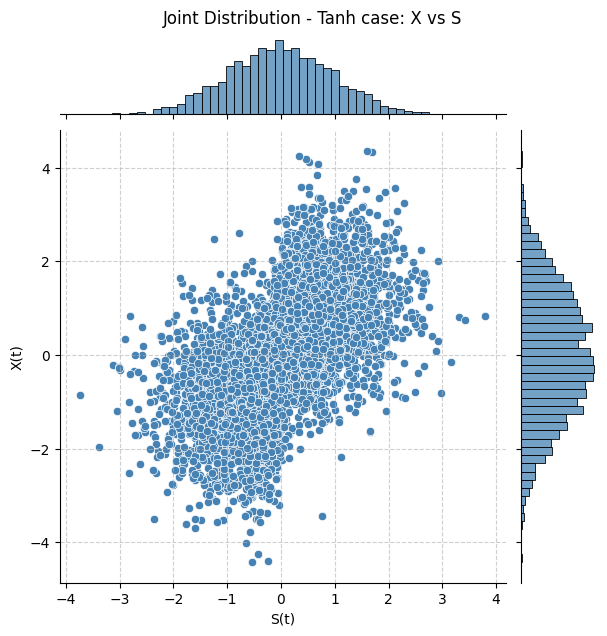

In [6]:
# ------ Tanh, no AR, no LAG ------------
X_tanh = hp.generate_neural_variable(S, relation="tanh")
#hp.plot_ts_and_hist(X_tanh, r"$X(t) = \tanh{S(t)} + \eta$", color = "goldenrod")
#hp.plot_joint_distribution(S, X_tanh,
#                           title_string="Tanh case: X vs S",
#                           color="goldenrod")


hp.plot_joint_distribution_sns(S, X_tanh, title_string = "Tanh case: X vs S")

### Non-monotonic 
$$
X(t) = S(t)^2 + \eta(t)
$$

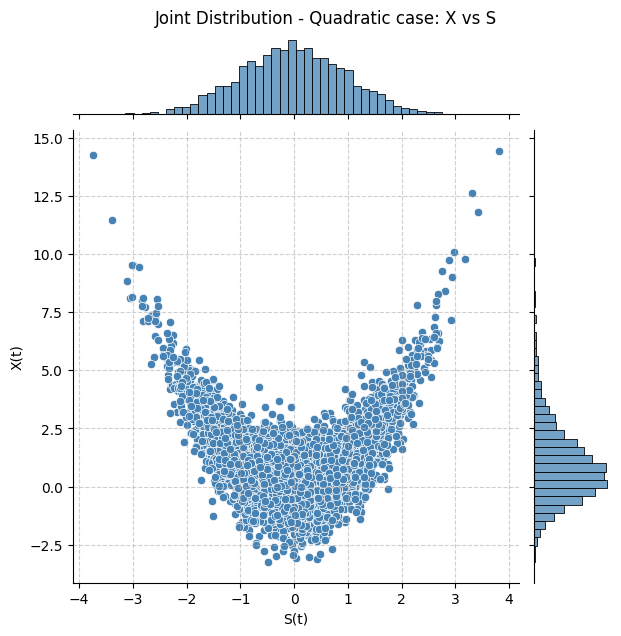

In [7]:
X_quad = hp.generate_neural_variable(S, relation= "quadratic")
#hp.plot_hist(X_quad, r"$X(t) = S(t)^2 + \eta$", color = "darkorange")
#hp.plot_joint_distribution(S, X_quad,
#                           title_string="Quadratic case: X vs S",
#                           color="darkorange")

hp.plot_joint_distribution_sns(S, X_quad, title_string = "Quadratic case: X vs S")

# ESTIMATING MI FROM SIMULATED DATA

Comparison of various methods with the ground truth. Analyzed methods are:

1. binning (parameter: $\epsilon$ - bin width)
2. KDE (parameter: $v^2$ kernel smoothness)
3. Gaussian Copula (parameters: none)


Analysis of dependence upon:

- amplitude of the stochastic noise, $\sigma^2$
- number of data samples, $N$.

## Ground truth calculations



**Relations between the differential quantities:**

At difference with the discrete case, the differential entropy is not invariant under a monotonic transformation. 


- If X = f(S) with f monotonic, it holds that:

    $$
    h(X) = h(S) + \mathbb{E}\left[\ln |f'(S)|\right]
    $$

- If $X = f(S) + \sigma \cdot \eta$ with f monotonic (**Gaussian noisy channel**), it is not possible to compute analytically the entropy of X, except for a few special cases (gaussian S and linear f)

    $$
    h(X) = h(f(S) + \eta )  = \mathbf{?}
    $$

    Therefore, we need to resort to **numeric integration** to have a ground truth value for h(X).

.

.

.



Also, at difference with the discrete case, it is no longer true that if $X = f(S)$, then $h(X|S) = 0$. Instead, if $X= f(S)$ it holds that $h(X|S) = - \infty$.

To work with finite numbers, it is convenient to add some noise $X =  f(S) + \sigma \cdot \eta$, so that $h(X|S)$ is the differential entropy of a normal variable, 

$$
h(X|S) = \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma^2]
$$

.

.

.


Putting everything together, the differential mutual information will be given by:

$$
mi(X:S) = h(X) - h(X|S) \simeq \left[ h(X)^{num} \right] - \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma^2] \geq 0
$$

where $h(X)^{num}$ is an estimate obtained through numeric integration or montecarlo.


$mi(X:S)\geq 0$ always and $mi(X:S)\rightarrow +\infty$ for $\sigma \rightarrow 0$ (deterministic case). 


This actually makes sense, although can be a little confusing:

*Because S is a continuous variable, it technically contains an infinite amount of information (it takes an infinite number of decimal places to specify its exact value). If X=f(S) and f is monotonic, then knowing S tells you X with infinite precision. Therefore, the information they share is infinite.*

-------------------------

**Channel capacity of a Gaussian channel**

Since we are generating the response variable adding a gaussian white noise, $X = f(S) + \sigma \cdot \eta$, we are inside the framework of a gaussian noisy channel. The differential mutual information between X and S depends on i) the distribution of the source, ii) the functional form of f, but in any case it is upper bounded by the channel capacity.

.

.


Restricting to source variables $Z=f(S)$ with $E[Z] = 0, E[z^2] \leq v^2$


$$
0 \leq mi(X:Z) \leq C = max_{p(Z)} \left\{mi(X:Z)\right\} = \frac{1}{2} \log_2 [1 + \left(\frac{v}{\sigma}\right)^2]
$$

In particular:

- if S is normally distributed and $f$ is a linear function, then  also Z is normally distributed, and the mi between X and Z ($\equiv mi(X:S)$) is the channel capacity.

-------------------------

In [ ]:
S = np.random.normal(0, 1, Ntsteps)
H_S = 



## Binning

We are interested in estimating the *differential mutual information (mi)* between the continuous r.v.s. X and S. The *binning* method makes use of this fact:





If X, S are the continuous r.v.s and $X_\epsilon, S_\epsilon$ are their discretized (binned) versions,

$$
lim_{\epsilon \rightarrow 0^+} MI(X_{\epsilon}: S_{\epsilon}) = mi(X, S)
$$



-------------------
**Relations between the discretized quantities:**

 - If X is a deterministic function of S, $H(X_\epsilon|S_\epsilon) = 0$. Hence:

    $$
    MI(X_{\epsilon}: S_{\epsilon}) = H(X_{\epsilon}) - H(X_\epsilon|S_\epsilon) \equiv  H(X_{\epsilon})
    $$

    Entropies of the response X and the source S are linked by the *data processing inequality*, which states that:

    $$
    \text{if} \quad X = f(S), \quad \text{then} \quad H(X) \leq H(S)
    $$


    In particular, if $f$ is a **bijective** function, $H(X) \equiv H(S)$. In this case, therefore, 

    $$
    MI(X_{\epsilon}: S_{\epsilon}) = H(S_{\epsilon}).
    $$


-------------------------
Differential entropy of a gaussian r.v.

$$
h(S) = \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma_S^2]
$$

$$
H(S_\epsilon) = h(S) + \log_2\left(\frac{1}{\epsilon}\right) + \mathcal{O}(\epsilon)
$$

-------------------------


## M.I. ASSUMING JOINT NORMALITY
If $X$ and $S$ are jointly Gaussian, the mutual information is: 
$$
I(X; S) = - \frac{1}{2}\log_2(1 - \rho^2)
$$
where: 
$$
\rho = corr(X,S) \text{\ \ is the Pearson correlation coefficient}. 
$$

_NOTICE:_ 
A pair (U,V) is jointly Gaussian if EVERY LINEAR COMBINATION of aU+bV is Gaussian ($\forall a, b \in \mathbb{R}$). Thus, having U and V Gaussian is not sufficient (although necessary): you need independence OR a known linear relationship to guarantee joint Gaussianity. 

This is why in our linear case MI is correct, while in the other cases it may be non-zero but not-exact or even not capture any correlation at all, even though correlations are present. 

In [8]:
# Example: 
mi_linear = hp.gaussian_mi(X_linear, S)
print(f"MI (linear) = {mi_linear:.3f} bits")

mi_cub = hp.gaussian_mi(X_cub, S)
print(f"MI (cubic) ≈ {mi_cub:.3f} bits (Gaussian approx)")

mi_tanh = hp.gaussian_mi(X_tanh, S)
print(f"MI (tanh) ≈ {mi_tanh:.3f} bits (Gaussian approx)")

mi_quad = hp.gaussian_mi(X_quad, S)
print(f"MI (quad) ≈ {mi_quad:.3f} bits (Gaussian approx)")

MI (linear) = 0.496 bits
MI (cubic) ≈ 0.598 bits (Gaussian approx)
MI (tanh) ≈ 0.304 bits (Gaussian approx)
MI (quad) ≈ 0.000 bits (Gaussian approx)


**NOTICE:**
Variations (maybe in some sistematic way) can be tried and commented (as for considering AR or lag presence cases). 

# **TO THINK AND MAYBE GO ON FROM HERE** ... do we have a way to compute the exact (analytical) MI to compare with Gaussian MI here?

# **REAL DATA**